# Escalado
Conjunto de datos: iris (incluido en sklearn)
Este conjunto de datos es compacto y perfecto para demostrar técnicas de escalado.

In [1]:
# Importar librerías necesarias
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Cargar el conjunto de datos
iris = load_iris(as_frame=True)
data = iris.data

In [3]:
# Visualizar las estadísticas iniciales
print("Estadísticas iniciales:")
data.describe()

Estadísticas iniciales:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
# Aplicar MinMaxScaler
minmax_scaler = MinMaxScaler()
data_minmax = pd.DataFrame(minmax_scaler.fit_transform(data), columns=data.columns)

In [6]:
# Aplicar StandardScaler
standard_scaler = StandardScaler()
data_standard = pd.DataFrame(standard_scaler.fit_transform(data), columns=data.columns)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre las estadísticas originales y las del escalado MinMax?


In [7]:
print("Estadísticas originales:")
print(data.describe())

print("\nEstadísticas escaladas con MinMax:")
print(data_minmax.describe())

Estadísticas originales:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

Estadísticas escaladas con MinMax:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150

MinMaxScaler no cambia la forma de los datos ni las relaciones entre observaciones, solo cambia la escala y leva todo a un rango común [0,1], lo cual es muy útil cuando tienes columnas con unidades o rangos muy distintos entre sí

### 2. Crea una gráfica de la distribución de la variable 'sepal length (cm)' antes y después del escalado.

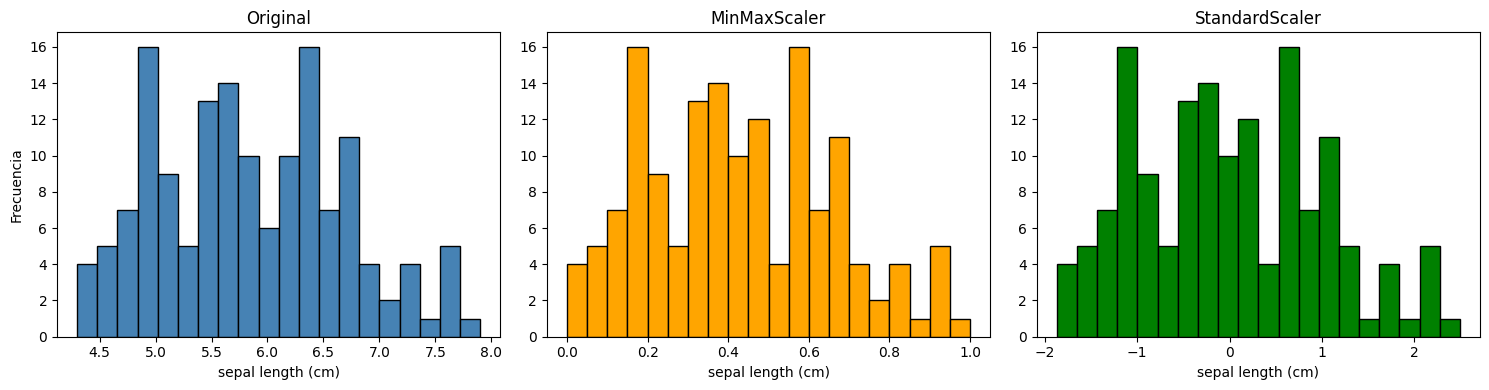

In [8]:
plt.figure(figsize=(15, 4))

# Original
plt.subplot(1, 3, 1)
plt.hist(data['sepal length (cm)'], bins=20, color='steelblue', edgecolor='black')
plt.title('Original')
plt.xlabel('sepal length (cm)')
plt.ylabel('Frecuencia')

# MinMax
plt.subplot(1, 3, 2)
plt.hist(data_minmax['sepal length (cm)'], bins=20, color='orange', edgecolor='black')
plt.title('MinMaxScaler')
plt.xlabel('sepal length (cm)')

# Standard
plt.subplot(1, 3, 3)
plt.hist(data_standard['sepal length (cm)'], bins=20, color='green', edgecolor='black')
plt.title('StandardScaler')
plt.xlabel('sepal length (cm)')

plt.tight_layout()
plt.show()

Las tres distribuciones deberían tener exactamente la misma forma (mismos picos, misma asimetría) — porque tanto MinMax como Standard son transformaciones lineales, que no distorsionan la forma de los datos, solo cambian la escala del eje X.

### 3. Crea una gráfica de dispersión entre 'sepal length (cm)' y 'sepal width (cm)' con los datos escalados por StandardScaler.

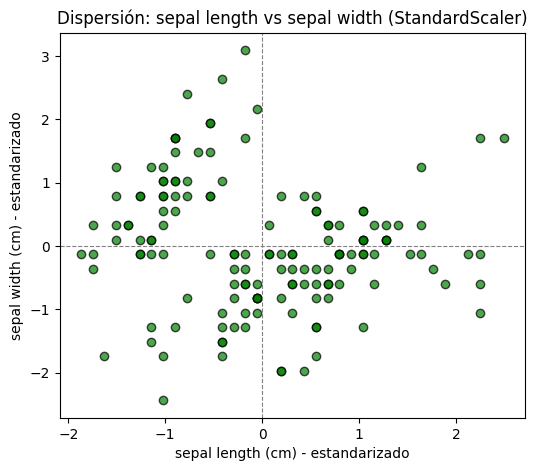

In [9]:
plt.figure(figsize=(6, 5))
plt.scatter(data_standard['sepal length (cm)'], data_standard['sepal width (cm)'], color='green', alpha=0.7, edgecolor='black')

plt.xlabel('sepal length (cm) - estandarizado')
plt.ylabel('sepal width (cm) - estandarizado')
plt.title('Dispersión: sepal length vs sepal width (StandardScaler)')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.show()

### 4. ¿Qué técnica de escalado crees que es más adecuada para este conjunto de datos? ¿Por qué?

Para el dataset Iris, StandardScaler suele ser la opción más adecuada, principalmente porque es el estándar más usado en la práctica para tareas de clasificación (que es el uso típico de este dataset) y porque no está limitado a un rango fijo, lo cual lo hace más robusto si se agregan nuevos datos fuera del rango de entrenamiento. Sin embargo, dado que las 4 variables de Iris ya están en la misma unidad (cm) y no presentan outliers severos, la diferencia práctica entre usar uno u otro no sería muy dramática — a diferencia de un dataset con variables en escalas muy distintas, donde la elección del escalador tendría un impacto mucho mayor en el resultado final.